# Begin

In [1]:
# @launchit.collected

In [2]:
import os # @launchit.collect
import sys # @launchit.collect
import copy
from collections import namedtuple, defaultdict # @launchit.collect
import json
import datetime
import pprint
from functools import cache
import re
import pickle
from unittest.mock import Mock
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import importlib.util
import IPython
from enum import StrEnum, auto # @launchit.collect
import multiprocessing as mp

from tqdm.notebook import tqdm

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as pltpatches
import scipy.io
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import KFold

import torch
import torch.nn as tnn
import torch.nn.functional as tnnf
import torch.optim as topt
from torch.utils.data import DataLoader, StackDataset
from torchvision import datasets

import optuna 
from optuna.storages import JournalStorage 
from optuna.storages.journal import JournalFileBackend 
from optuna.trial import TrialState

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
from utils import * # @launchit.collect
from logging_utils import *
from model_registry import *
import launchit # @launchit.disable
import optuna_multiprocessing  # @launchit.collect_2
from metrics_collector import RmqSummaryWriter
from autoincrement import Autoincrement

# Setup

In [3]:
class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

LOG = Logging.get()
RNG = np.random.default_rng()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, subproject_path, data_path, mnist_path, run_path, ' + 
                    'self_fname, self_name, ' +
                    'subproject_name,' +
                    'is_cuda, cuda_device, is_cuml, exec_mode, is_interactive')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    subproject_path=os.path.abspath('.'),
    data_path=os.path.join(project_root_path, 'data'),
    mnist_path=os.path.join(project_root_path, 'data', 'mnist'),
    run_path='',
    self_fname='',
    self_name='',
    subproject_name='',
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    is_cuml=importlib.util.find_spec('cuml') is not None,
    exec_mode=ExecMode.MASTER_NOTEBOOK,
    is_interactive=True,
)

if IPython.get_ipython() is None:
    module_fname = __file__
    module_basename = os.path.basename(module_fname)
    module_name, _ = os.path.splitext(module_basename)
    
    CONFIG = CONFIG._replace(self_fname=module_fname, self_name=module_name)
    CONFIG = CONFIG._replace(exec_mode=ExecMode.LAUNCH_MODULE)
else:
    with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
        notebook_fname = json.load(cf)['jupyter_session']
        notebook_basename = os.path.basename(notebook_fname)
        notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    
        m = re.match(r'(\w+)-Copy\d+$', notebook_name)
    
        if m:
            # Cuml is used to be launched from the copy of the notebook
            notebook_name = m.group(1)

        CONFIG = CONFIG._replace(self_fname=notebook_fname, self_name=notebook_name)
        
        is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
        CONFIG = CONFIG._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)

CONFIG = CONFIG._replace(is_interactive=CONFIG.exec_mode != ExecMode.LAUNCH_MODULE)

LOG.app_name = CONFIG.self_name
LOG.enable('syslog', not CONFIG.is_interactive)
LOG.enable('stdout', CONFIG.is_interactive)

CONFIG = CONFIG._replace(subproject_name=os.path.basename(os.path.dirname(CONFIG.self_fname)))
CONFIG = CONFIG._replace(run_path=os.path.join(project_root_path, 'run', CONFIG.subproject_name))
LOG('CONFIG=\n' + pprint.pformat(CONFIG._asdict()))
LOG('')

os.makedirs(CONFIG.run_path, exist_ok=True)

# @launchit.disable
# @launchit.collect
class LaunchGoal(StrEnum):
    UNSPECIFIED = auto()
    PRETRAIN_LOSS = auto()
    E2E = auto()
    TEST_ACCURACY = auto()

LAUNCH_PROBLEM = namedtuple('LaunchProblem', 'goal, model_group_uri, model_name, model_version, model_main_asset_fname')(
    goal=LangUtils.from_str(LaunchGoal, '${LAUNCH_GOAL}', LaunchGoal.UNSPECIFIED),
    model_group_uri='${MODEL_GROUP_URI}',
    model_name='${MODEL_NAME}',
    model_version=LangUtils.from_str(int, '${MODEL_VERSION}', 0),
    model_main_asset_fname='${LAUNCHIT_FNAME}',
)
# @launchit.stop

LAUNCH_PROBLEM = LAUNCH_PROBLEM._replace(goal=LaunchGoal.UNSPECIFIED)
LAUNCH_PROBLEM = LAUNCH_PROBLEM._replace(model_group_uri=f'{CONFIG.project_root_uri}.{CONFIG.subproject_name}')
LAUNCH_PROBLEM = LAUNCH_PROBLEM._replace(model_name=CONFIG.self_name)
LAUNCH_PROBLEM = LAUNCH_PROBLEM._replace(model_version=0)
LAUNCH_PROBLEM = LAUNCH_PROBLEM._replace(model_main_asset_fname=CONFIG.self_fname)
# @launchit.stop

LOG('LAUNCH_PROBLEM=\n' + pprint.pformat(LAUNCH_PROBLEM._asdict()))

METRICS_SUITE = defaultdict(list)

CONFIG=
{'cuda_device': 'cuda',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_cuda': True,
 'is_cuml': False,
 'is_interactive': True,
 'mnist_path': '/home/misha/dev/mine/neurovision/data/mnist',
 'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'run_path': '/home/misha/dev/mine/neurovision/run/denoise',
 'self_fname': '/home/misha/dev/mine/neurovision/denoise/s3_stacked_dae_09.ipynb',
 'self_name': 's3_stacked_dae_09',
 'subproject_name': 'denoise',
 'subproject_path': '/home/misha/dev/mine/neurovision/denoise'}

LAUNCH_PROBLEM=
{'goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'model_group_uri': 'com.develorium.neurovision.denoise',
 'model_main_asset_fname': '/home/misha/dev/mine/neurovision/denoise/s3_stacked_dae_09.ipynb',
 'model_name': 's3_stacked_dae_09',
 'model_version': 0}


# Hyperparameters

In [4]:
# @launchit.disable
# @launchit.collect
@dataclass
class Hyperparameters:
    random_seed: int = None
    override_pretrain_model_version: int = None
    
    @dataclass
    class Images:
        preprocessing: str = None
        
    @dataclass
    class PretrainModel:
        daes_count: int = None
        filters_count: int = None
        is_tied_weights: bool = None
        is_bias: bool = None
        nonlinearity: dict = None
        inp_dropout: float = None
        hid_dropout: float = None

    @dataclass
    class Pretraining:
        batch_size: int = None
        epochs_count: int = None
        optimizer: str = None
        learn_rate: float = None
        noise: str = None
        loss: str = None
        regularization: dict = None

    @dataclass
    class Training:
        batch_size: int = None
        epochs_count: int = None
        optimizer: str = None
        learn_rate: float = None
        cv_folds_count: int = None
        
    images: Images = dataclasses.field(default_factory=Images)
    pretrain_model: PretrainModel = dataclasses.field(default_factory=PretrainModel)
    pretraining: Pretraining = dataclasses.field(default_factory=Pretraining)
    training: Training = dataclasses.field(default_factory=Training)

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        hp.images = Hyperparameters.Images(**hp.images)
        hp.pretrain_model = Hyperparameters.PretrainModel(**hp.pretrain_model)
        hp.pretraining = Hyperparameters.Pretraining(**hp.pretraining)
        hp.training = Hyperparameters.Training(**hp.training)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

HP = Hyperparameters()
HP.random_seed = 82
HP.override_pretrain_model_version = None


# Launch

## new_model_registry

In [5]:
def new_model_registry(is_real=None):
    is_launch = CONFIG.exec_mode in [ExecMode.LAUNCH_NOTEBOOK, ExecMode.LAUNCH_MODULE]
    is_real = is_real if is_real is not None else is_launch

    if not is_real:
        mr = Mock()
        mr.register_model.return_value = 0
        return mr
        
    return ModelRegistry(LAUNCH_PROBLEM.model_group_uri)

## new_summary_writer

In [6]:
def new_summary_writer(log_dir, is_real=None):
    is_launch = CONFIG.exec_mode in [ExecMode.LAUNCH_NOTEBOOK, ExecMode.LAUNCH_MODULE]
    is_real = is_real if is_real is not None else is_launch

    if not is_real:
        sw = Mock()
        sw.flush.side_effect = sw.reset_mock # to get rid of all recorded call_args_list, which might be heavy (e.g. add_figure)
        return sw
    
    return RmqSummaryWriter(log_dir)

## Bootstrap

In [7]:
optuna_trial = optuna_multiprocessing.get_trial()

if optuna_trial is not None:
    optuna_trial.set_user_attr('MODEL_VERSION', LAUNCH_PROBLEM.model_version)
    LOG(f'Optuna {optuna_trial.number=}, {OPTUNA_TRIAL.user_attrs=}')
    
if HP.random_seed is not None:
    torch.manual_seed(HP.random_seed)
    RNG = np.random.default_rng(HP.random_seed)    
    LOG(f'Random seed={HP.random_seed}')

if LAUNCH_PROBLEM.goal != LaunchGoal.TEST_ACCURACY:
    model_registry = new_model_registry()
    model_registry.attach_asset(LAUNCH_PROBLEM.model_name, LAUNCH_PROBLEM.model_version, CONFIG.self_fname, replace=True)
        
    meta = dict(
        optuna_trial_number=getattr(optuna_trial, 'number', None),
        hypers=HP._asdict(), 
        config=CONFIG._asdict(), 
    )
    
    with io.StringIO() as b:
        json.dump(meta, b)
        model_registry.attach_asset(LAUNCH_PROBLEM.model_name, LAUNCH_PROBLEM.model_version, b, asset_ext='json', asset_classifier='meta', replace=True)

summary_log_dir = os.path.join(LAUNCH_PROBLEM.model_name, str(LAUNCH_PROBLEM.model_version))
LOG(f'Tensorboard run={summary_log_dir}')
summary_writer = new_summary_writer(log_dir=summary_log_dir)
summary_writer.add_text('hypers', pprint.pformat(HP._asdict()), 1)
summary_writer.add_text('config', pprint.pformat(CONFIG._asdict()), 1)

Random seed=82
Tensorboard run=s3_stacked_dae_09/


<Mock name='mock.add_text()' id='129268517135776'>

# Images

In [92]:
# @launchit.disable
# @launchit.collect_1
HP.images.preprocessing = 'UNINORM' # NONE, UNINORM, MIN_MAX, STANDARDIZE, ZCA_WHITEN, ZCA_HFR30_WHITEN

## get_mnist_images

In [93]:
def get_mnist_images(subdataset='TRAIN'):
    assert subdataset in ['TRAIN', 'TEST'], f'Unsupported subdataset={subdataset}'
    d = datasets.MNIST(CONFIG.mnist_path, train=subdataset=='TRAIN', download=True)
    images = d.data.reshape(len(d.data), -1)
    images = images.numpy()
    images = images.astype('float32')
    image_labels = d.targets
    return images, image_labels

## UninormScaler

In [94]:
class UninormScaler:
    def __init__(self, divisor=255.0):
        self.divisor = divisor
        
    def fit_transform(self, images):
        return self.transform(images)

    def transform(self, images):
        return images / self.divisor

## preprocess_images

In [95]:
def preprocess_images(images, preprocessing_method, scaler=None):
    match preprocessing_method:
        case 'UNINORM':
            scaler = UninormScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'MIN_MAX':
            scaler = MinMaxScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'STANDARDIZE':
            scaler = StandardScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'ZCA_WHITEN':
            scaler = StandardScaler(with_std=False) if scaler is None else scaler
            images = scaler.fit_transform(images)
            
            Σ = np.cov(images, rowvar=False)
            u, s, _ = np.linalg.svd(Σ)
            images = (u @ np.diag(1.0 / np.sqrt(s + 1e-6)) @ u.T @ images.T).T
        case 'ZCA_HFR30_WHITEN': # HFR30 - Remove 30% of High Frequencies
            scaler = StandardScaler(with_std=False) if scaler is None else scaler
            images = scaler.fit_transform(images)
    
            Σ = np.cov(images, rowvar=False)
            eigvals, eigvecs = np.linalg.eig(Σ)
            eigvals_order = np.argsort(-eigvals)
            wipeout_inds = eigvals_order[int(len(eigvals_order) * (1 - 0.3)):]
            eigvals_w = eigvals.copy()
            eigvals_w[wipeout_inds] = 0
            
            R, S = eigvecs, np.diag(np.sqrt(eigvals_w)) # R - rotation matrix, S - scale matrix
            S_inv = np.reciprocal(S, out=np.zeros_like(S), where=(S != 0))
            R_inv = R.T
            W = R @ S_inv @ R_inv  # equiv. to: R @ np.eye(len(S_inv)) @ S_inv @ R_inv
            images = (W @ images.T).T
        case 'NONE':
            pass
        case _:
            assert False, f'Unsupported preprocessing_method={preprocessing_method}'

    return images, scaler

# Noising

## gauss_noise

In [96]:
def gauss_noise(items, gadds_tab):
    if items.ndim == 2:
        assert items.shape[1] == gadds_tab.shape[1], f'Shape mismatch: {items.shape[1]} vs {gadds_tab.shape[1]}'
        items_count = len(items)
        noise = gadds_tab[RNG.choice(len(gadds_tab), items_count)]
    elif items.ndim == 1:
        gadd_ind = RNG.choice(len(gadds_tab))
        noise = gadds_tab[gadd_ind]
    else:
        assert False, f'Unsupported dimensions count for items: {items.ndim}'

    if isinstance(items, np.ndarray):
        return items + noise
    elif isinstance(items, torch.Tensor):
        return items + torch.tensor(noise, device=items.device, dtype=items.dtype)

## masking_noise

In [97]:
def masking_noise(items, masks_tab, fill_value=0):
    if items.ndim == 2:
        assert items.shape[1] == masks_tab.shape[1], f'Shape mismatch: {items.shape[1]} vs {masks_tab.shape[1]}'
        items_count = len(items)
        mask_inds = RNG.choice(len(masks_tab), items_count, replace=False)
        boolmap = masks_tab[mask_inds]
    elif items.ndim == 1:
        mask_ind = RNG.choice(len(masks_tab))
        boolmap = masks_tab[mask_ind]
    else:
        assert False, f'Unsupported dimensions count for items: {items.ndim}'

    if isinstance(items, np.ndarray):
        noised = items.copy()
    elif isinstance(items, torch.Tensor):
        noised = items.clone()
    else:
        assert False, f'Unsupported type(items): {type(items)}'

    noised[boolmap] = fill_value
    return noised

## generate_zmasks

In [98]:
def generate_zmasks(ν, item_size, count):
    assert 0 <= ν <= 1
    zero_inds_count = int(ν * item_size)
    zmasks = np.full((count, item_size), False)
    
    for i in range(count):
        zero_inds = RNG.choice(item_size, zero_inds_count, replace=False)
        zmasks[i,zero_inds] = True

    return zmasks    

## Demo

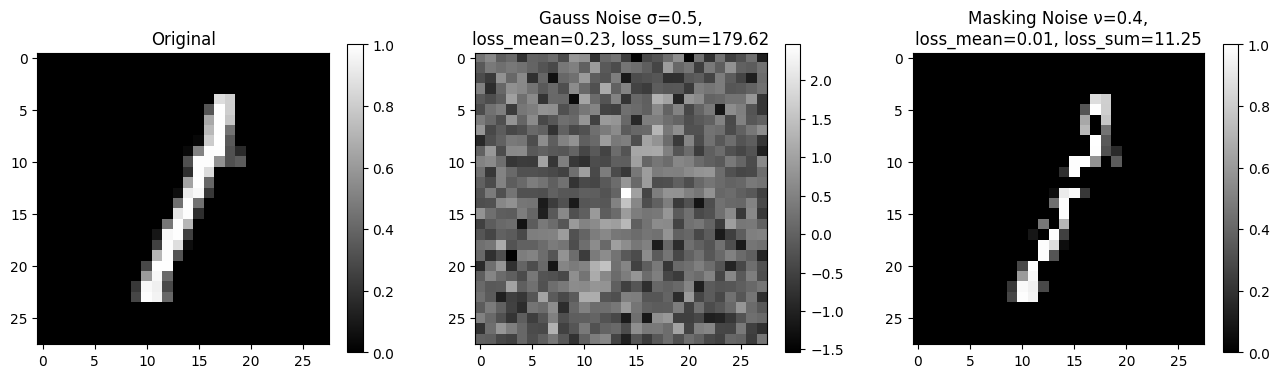

In [99]:
# @launchit.disable
images, _ = get_mnist_images()
images, _ = preprocess_images(images, HP.images.preprocessing)
image_ind = RNG.choice(len(images))
image = images[image_ind]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figwidth(16)
fig.set_figheight(8)
ax1.set_title('Original')
im = ax1.imshow(ArrayUtils.v2sm(image), cmap='gray');
fig.colorbar(im, ax=ax1, shrink=.5)

σ = 0.5
gadds = RNG.normal(0, σ, (100, image.shape[0]))
noised = gauss_noise(image.ravel(), gadds)
noised = noised.reshape(image.shape)
ax2.set_title(f'Gauss Noise σ={σ},\nloss_mean={((image - noised)**2).mean():.2f}, loss_sum={((image - noised)**2).sum():.2f}')
im = ax2.imshow(ArrayUtils.v2sm(noised), cmap='gray');
fig.colorbar(im, ax=ax2, shrink=.5)

ν = 0.4
zmasks = generate_zmasks(ν, image.shape[0], 100)
noised = masking_noise(image.ravel(), zmasks, fill_value=0)
noised = noised.reshape(image.shape)
ax3.set_title(f'Masking Noise ν={ν},\nloss_mean={((image - noised)**2).mean():.2f}, loss_sum={((image - noised)**2).sum():.2f}')
im = ax3.imshow(ArrayUtils.v2sm(noised), cmap='gray');
fig.colorbar(im, ax=ax3, shrink=.5);

# Unsupervised pretraining

## Dataset

In [100]:
# @launchit.disable_1
pretrain_dataset, _ = get_mnist_images('TRAIN')
pretrain_dataset, _ = preprocess_images(pretrain_dataset, HP.images.preprocessing)
pretrain_dataset = torch.Tensor(pretrain_dataset)
pretrain_dataset = pretrain_dataset.contiguous() # force dense memory layout (speeds up DataLoader x2)

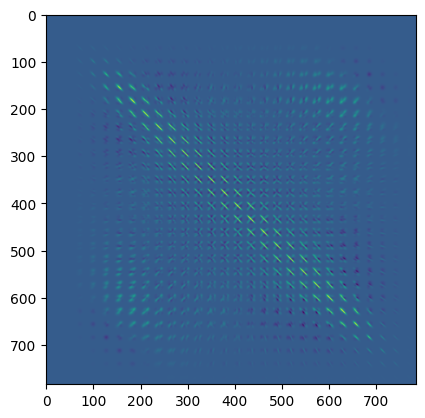

In [101]:
# @launchit.disable
plt.imshow(np.cov(pretrain_dataset, rowvar=False));

## Model: StackedDAE

In [102]:
class DenoiseAutoencoder(tnn.Module):
    def __init__(self, dae_ind, inp_dims_count, model_hp):
        super().__init__()
        # all weights are initialized by default via init.kaiming_uniform_ 
        self.encoder = tnn.Linear(inp_dims_count, model_hp.filters_count, bias=model_hp.is_bias) # aka filters

        if model_hp.is_tied_weights:
            self.decoder = None
            self.decoder_bias = tnn.Parameter(torch.randn(inp_dims_count)) if model_hp.is_bias else None
        else:
            self.decoder = tnn.Linear(model_hp.filters_count, inp_dims_count, bias=model_hp.is_bias)
            self.decoder_bias = None

        nop = lambda x: x # aka identity
        nonlinearities = {None: nop, 'sigmoid': tnnf.sigmoid}
        nonlinearity = {} if model_hp.nonlinearity is None else model_hp.nonlinearity
        self.encoder_nonlinearity = nonlinearities[nonlinearity.get('encoder', None)]
        self.decoder_nonlinearity = nonlinearities[nonlinearity.get('decoder', None)]

        dropout_p = model_hp.inp_dropout if dae_ind == 0 else model_hp.hid_dropout
        dropout_p = 0 if dropout_p is None else dropout_p
        self.dropout = tnn.Dropout(dropout_p)

    ForwardResult = namedtuple('ForwardResult', 'reconstructed, activations, noised, noised_scale_factor')
    
    def forward(self, inp):
        if self.dropout.p > 0:
            noised = self.dropout(inp)
            # From docs: "Furthermore, the outputs are scaled by a factor of 1/(1-p) during training"
            noised = noised * (1 - self.dropout.p)
        else:
            noised = inp # input is expected to be noised from outside

        encoded = self.encode(noised)
        decoded = self.decode(encoded)
        return DenoiseAutoencoder.ForwardResult(
            reconstructed=decoded, 
            activations=encoded, 
            noised=noised,
            noised_scale_factor=1)
            # # From docs: "Furthermore, the outputs are scaled by a factor of 1/(1-p) during training"
            # noised_scale_factor=1 / (1 - self.dropout.p))

    def encode(self, inp):
        encoded = self.encoder(inp)
        encoded = self.encoder_nonlinearity(encoded)
        return encoded

    def decode(self, inp):
        if self.decoder is None:
            # tied weights
            res = tnnf.linear(inp, self.encoder.weight.t(), self.decoder_bias)
        else:
            res = self.decoder(inp)
            
        return self.decoder_nonlinearity(res) 

class StackedDAE(tnn.Module):
    def __init__(self, inp_dims_count, model_hp):
        super().__init__()
        self.daes = tnn.ModuleList()

        current_inp_dims_count = inp_dims_count
        
        for i in range(model_hp.daes_count):
            dae = DenoiseAutoencoder(i, current_inp_dims_count, model_hp)
            current_inp_dims_count = model_hp.filters_count
            self.daes.append(dae)

    def encode(self, inp, daes_count=-1):
        daes_count = len(self.daes) if daes_count == -1 else daes_count
        
        for i in range(daes_count):
            dae = self.daes[i]
            inp = dae.encode(inp)

        return inp

In [103]:
# @launchit.disable
model_hp = Hyperparameters.PretrainModel(daes_count=3, filters_count=1000, is_tied_weights=True, is_bias=True, nonlinearity={'encoder': 'sigmoid', 'decoder': None})
pretrain_model = StackedDAE(pretrain_dataset.shape[1], model_hp)
sum([p.numel() for p in pretrain_model.parameters()]), pretrain_model

(2789784,
 StackedDAE(
   (daes): ModuleList(
     (0): DenoiseAutoencoder(
       (encoder): Linear(in_features=784, out_features=1000, bias=True)
       (dropout): Dropout(p=0, inplace=False)
     )
     (1-2): 2 x DenoiseAutoencoder(
       (encoder): Linear(in_features=1000, out_features=1000, bias=True)
       (dropout): Dropout(p=0, inplace=False)
     )
   )
 ))

In [104]:
# @launchit.disable
data_loader = DataLoader(pretrain_dataset, batch_size=100)
batch = next(iter(data_loader))

# ascention stage
with torch.no_grad():
    for i in range(len(pretrain_model.daes)):
        save_shape = batch.shape
        batch = pretrain_model.daes[i].encode(batch)
        LOG(f'Encoding by DAE_{i}, batch shape={save_shape}->{batch.shape}')

    forward_result = pretrain_model.daes[i](batch) # call "forward"
    LOG(f'Forward result: {forward_result}')

# descention stage
with torch.no_grad():
    for i in reversed(range(len(pretrain_model.daes))):
        save_shape = batch.shape
        batch = pretrain_model.daes[i].decode(batch)
        LOG(f'Decoding by DAE_{i}, batch shape={save_shape}->{batch.shape}')    

Encoding by DAE_0, batch shape=torch.Size([100, 784])->torch.Size([100, 1000])
Encoding by DAE_1, batch shape=torch.Size([100, 1000])->torch.Size([100, 1000])
Encoding by DAE_2, batch shape=torch.Size([100, 1000])->torch.Size([100, 1000])
Forward result: ForwardResult(reconstructed=tensor([[ 0.6783, -0.0259,  1.7423,  ..., -0.5582,  0.4215, -0.2058],
        [ 0.6782, -0.0258,  1.7423,  ..., -0.5583,  0.4214, -0.2059],
        [ 0.6786, -0.0259,  1.7424,  ..., -0.5583,  0.4214, -0.2060],
        ...,
        [ 0.6782, -0.0260,  1.7424,  ..., -0.5583,  0.4216, -0.2059],
        [ 0.6786, -0.0258,  1.7425,  ..., -0.5583,  0.4215, -0.2057],
        [ 0.6785, -0.0258,  1.7423,  ..., -0.5583,  0.4215, -0.2060]]), activations=tensor([[0.5166, 0.4726, 0.4292,  ..., 0.5079, 0.5361, 0.4992],
        [0.5168, 0.4727, 0.4294,  ..., 0.5080, 0.5361, 0.4991],
        [0.5167, 0.4726, 0.4291,  ..., 0.5081, 0.5361, 0.4989],
        ...,
        [0.5167, 0.4728, 0.4292,  ..., 0.5079, 0.5360, 0.4990],
 

## Pretraining

In [105]:
# @launchit.disable_1
@cache
def gadds(σ, item_size, gadds_count):
    return RNG.normal(0, σ, (gadds_count, item_size)).astype(float) 

@cache
def zmasks(ν, item_size, masks_count):
    return generate_zmasks(ν, item_size, masks_count)

In [ ]:
# @launchit.disable_1
# Masking noise can be achived via Dropout. Dropout is much faster since it can utilize GPU
noise_funcs = {
    'None': lambda items: items,
    'Gauss_0.5': lambda items: gauss_noise(items, gadds(0.5, items.shape[1], 250_000)),
    'Masking_0': lambda items: masking_noise(items, zmasks(0, items.shape[1], 250_000)),
    'Masking_0.1': lambda items: masking_noise(items, zmasks(0.1, items.shape[1], 250_000)),
    'Masking_0.25': lambda items: masking_noise(items, zmasks(0.25, items.shape[1], 250_000)),
    'Masking_0.25_1': lambda items: masking_noise(items, zmasks(0.25, items.shape[1], 250_000), fill_value=1),
    'Masking_0.3': lambda items: masking_noise(items, zmasks(0.3, items.shape[1], 250_000)),
    'Masking_0.4': lambda items: masking_noise(items, zmasks(0.4, items.shape[1], 250_000)),
    'Masking_0.5': lambda items: masking_noise(items, zmasks(0.5, items.shape[1], 250_000)),
    'Masking_0.55': lambda items: masking_noise(items, zmasks(0.55, items.shape[1], 250_000)),
    'Masking_0.6': lambda items: masking_noise(items, zmasks(0.6, items.shape[1], 250_000)),
}

losses = {
    # sigmoid is expected to be withing Model structure (decoder)
    'BCE': lambda: tnn.BCELoss(reduction='mean'), 
    # sigmoid is NOT expected to be within Model structure, since sigmoid is builtin into loss itself
    'BCEWithLogits': lambda: tnn.BCEWithLogitsLoss(reduction='mean'), 
    ### 
    'MSE': lambda: tnn.MSELoss(reduction='mean'),
}

regularizations = {
    # Over activations acting regularizers
    'log(1+a^2)': lambda a: torch.log(1 + a**2), # Olshausen (sparsenet)
    '|a|': lambda a: torch.abs(a), # L1 regularization
}

In [106]:
# @launchit.disable
# @launchit.collect_1
HP.pretrain_model.daes_count = 3
HP.pretrain_model.filters_count = 1_000
HP.pretrain_model.is_tied_weights = True
HP.pretrain_model.is_bias = True
HP.pretrain_model.nonlinearity = {'encoder': 'sigmoid', 'decoder': 'sigmoid'}
HP.pretrain_model.inp_dropout = 0.5
HP.pretrain_model.hid_dropout = 0.5

HP.pretraining.batch_size = 1_000
HP.pretraining.epochs_count = 1
HP.pretraining.noise = 'None' # right choice for Masking noise is to use dropout (it's much faster)
# HP.pretraining.noise = 'Masking_0.5'
HP.pretraining.optimizer = 'Adam'
HP.pretraining.learn_rate = 0.005
HP.pretraining.loss = 'BCE'
HP.pretraining.regularization = None
# @launchit.stop
# @launchit.stop
LOG(pprint.pformat(HP._asdict()))

{'images': {'preprocessing': 'UNINORM'},
 'override_pretrain_model_version': None,
 'pretrain_model': {'daes_count': 3,
                    'filters_count': 1000,
                    'hid_dropout': 0.5,
                    'inp_dropout': 0.5,
                    'is_bias': True,
                    'is_tied_weights': True,
                    'nonlinearity': {'decoder': 'sigmoid',
                                     'encoder': 'sigmoid'}},
 'pretraining': {'batch_size': 1000,
                 'epochs_count': 1,
                 'learn_rate': 0.005,
                 'loss': 'BCE',
                 'noise': 'None',
                 'optimizer': 'Adam',
                 'regularization': None},
 'random_seed': 82,
 'training': {'batch_size': None,
              'cv_folds_count': None,
              'epochs_count': None,
              'learn_rate': None,
              'optimizer': None}}


In [107]:
# @launchit.disable_1
def compute_regularized_loss(inferred, target, activations, loss_fn, regularization):
    loss = loss_fn(inferred, target) # args order: input, target

    if regularization is None or regularization['c'] <= 0:
        return loss
        
    c = regularization['c']
    reg_fn = regularizations[regularization['fn']]
    s = reg_fn(activations).sum(axis=1) # compute per sample 
    loss += (c * s).mean()
    return loss

In [108]:
# @launchit.disable_1
data_loader = DataLoader(pretrain_dataset.to(device=CONFIG.cuda_device), batch_size=HP.pretraining.batch_size, shuffle=True)
pretrain_model = StackedDAE(pretrain_dataset.shape[1], HP.pretrain_model)
pretrain_model = pretrain_model.to(device=CONFIG.cuda_device)
noise_func = noise_funcs[HP.pretraining.noise]
loss_fn = losses[HP.pretraining.loss]()
pretrain_model.train()
example_item_ind = RNG.choice(len(pretrain_dataset))

DAE:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

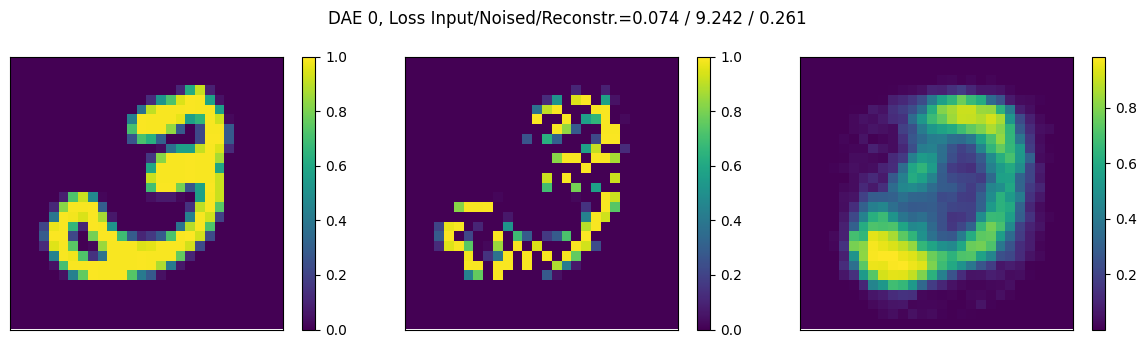

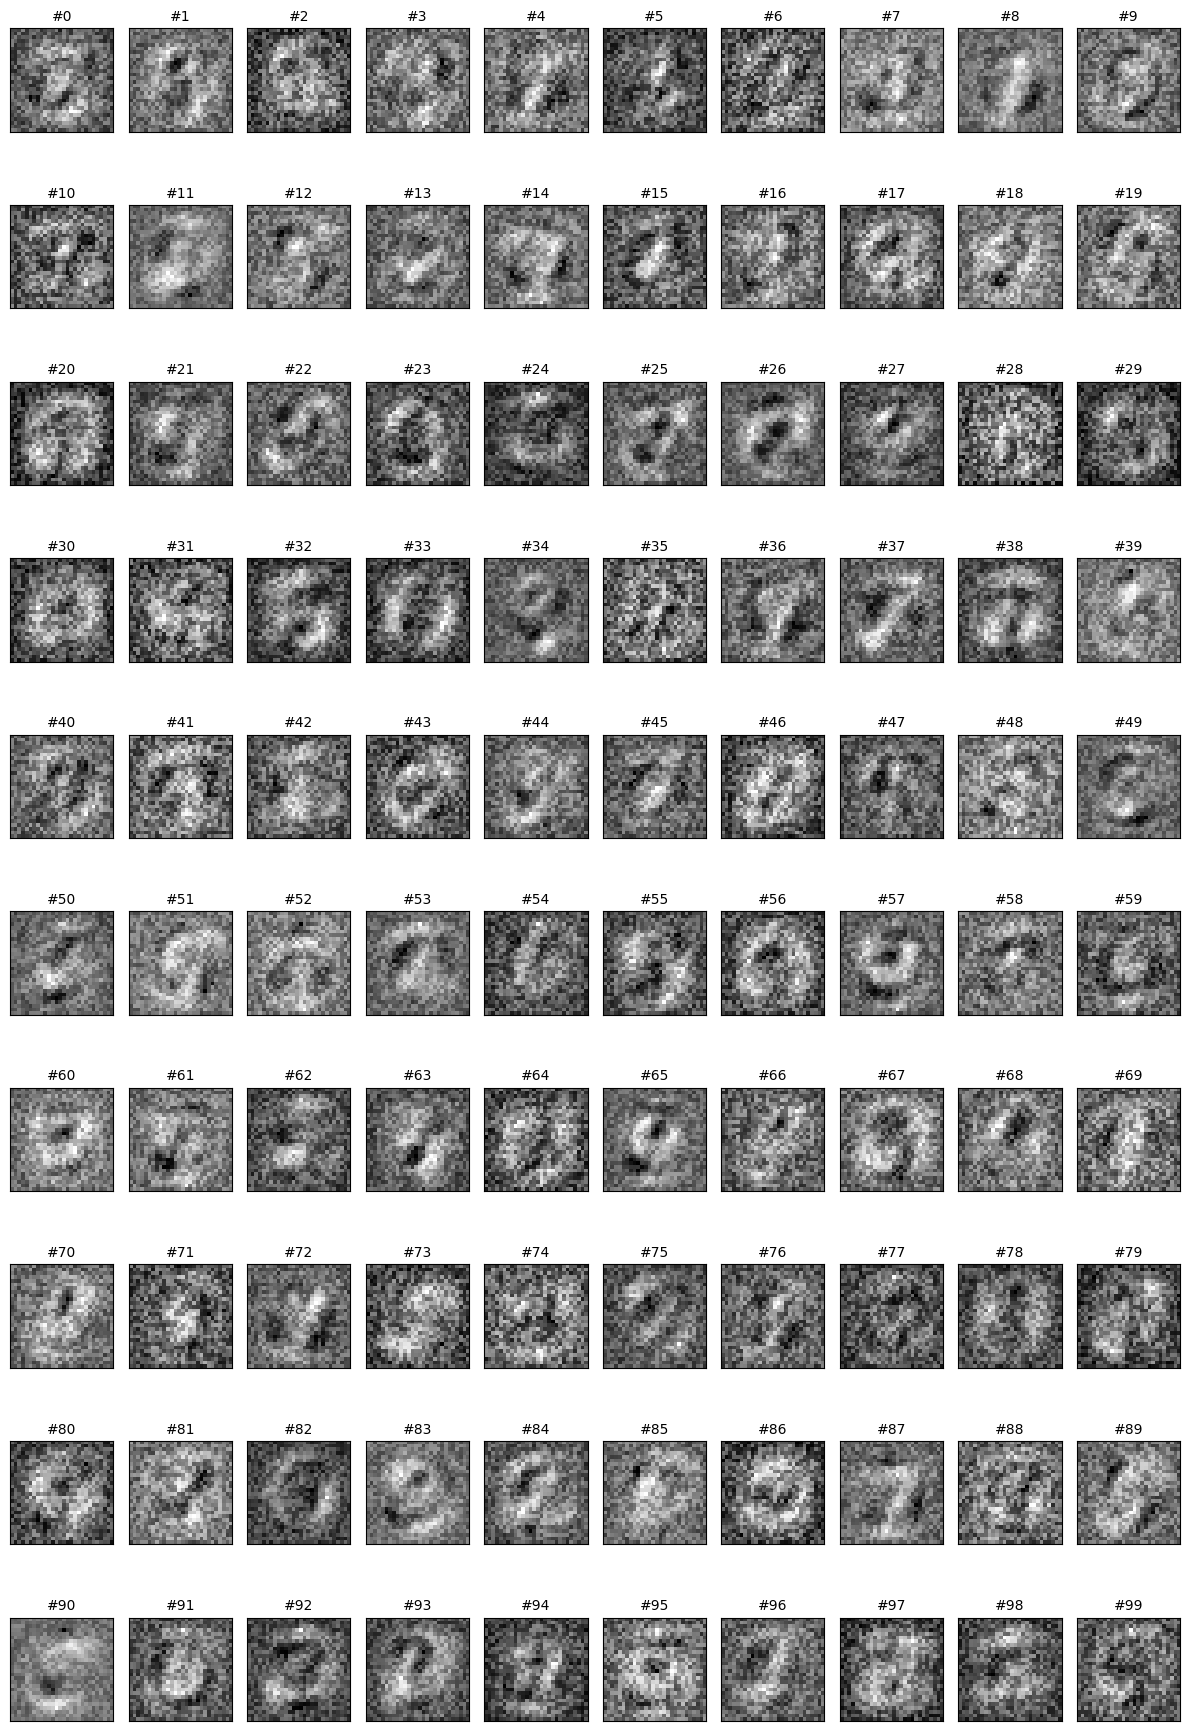

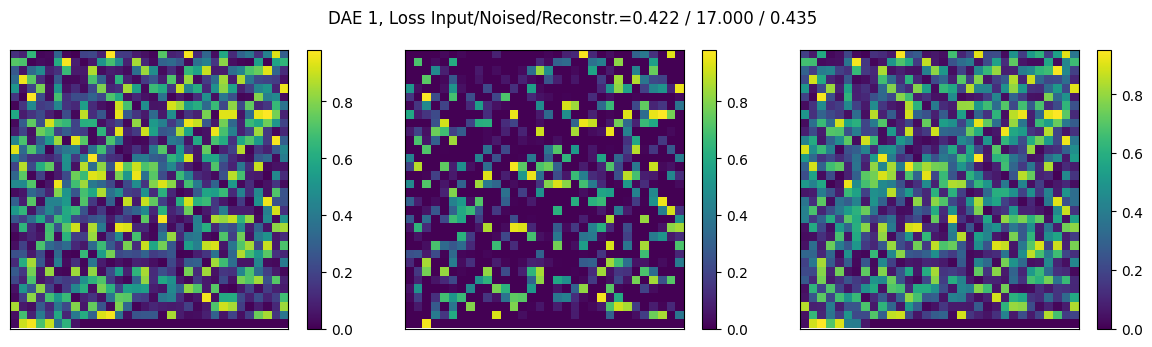

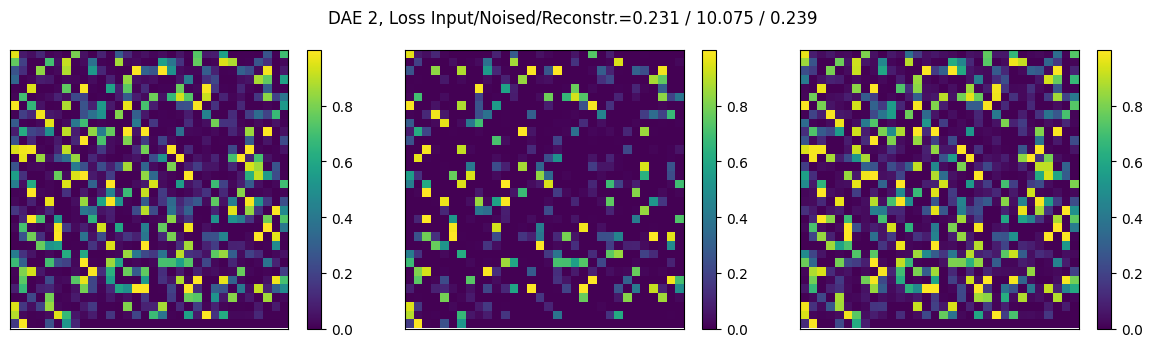

In [109]:
# @launchit.disable_1
for trained_dae_ind in tqdm(range(len(pretrain_model.daes)), 'DAE', disable=not CONFIG.is_interactive):
    with LOG.auto_prefix('DAE', trained_dae_ind):
        optimizer = getattr(topt, HP.pretraining.optimizer)(pretrain_model.parameters(), lr=HP.pretraining.learn_rate)
        
        for epoch_ind in tqdm(range(HP.pretraining.epochs_count), 'Epoch', disable=not CONFIG.is_interactive):
            local_epoch = epoch_ind + 1
            
            with LOG.auto_prefix('EPOCH', local_epoch):
                global_epoch = HP.pretraining.epochs_count * trained_dae_ind + local_epoch
                epoch_loss_sum, epoch_loss_denom = 0, 0
                
                for batch in data_loader:
                    optimizer.zero_grad()

                    with torch.no_grad():
                        assert 0 <= trained_dae_ind < len(pretrain_model.daes)
            
                        for i in range(trained_dae_ind):
                            batch = pretrain_model.daes[i].encode(batch)
            
                    noised = noise_func(batch)
                    fr = pretrain_model.daes[trained_dae_ind](noised)
            
                    loss = compute_regularized_loss(fr.reconstructed, batch, fr.activations, loss_fn, HP.pretraining.regularization)
                    loss.backward()
                    
                    optimizer.step()
                    
                    epoch_loss_sum += loss.item() * len(batch)
                    epoch_loss_denom += len(batch)
        
                assert epoch_loss_denom > 0
                epoch_loss = epoch_loss_sum / epoch_loss_denom
                summary_writer.add_scalar('pretrain_loss', epoch_loss, global_epoch)
                summary_writer.add_scalar(f'pretrain_loss_{trained_dae_ind}', epoch_loss, local_epoch)
                METRICS_SUITE[f'pretrain_loss_{trained_dae_ind}'].append(epoch_loss)

                LOG(f'pretrain_loss_{trained_dae_ind}={epoch_loss}', when=not CONFIG.is_interactive)
                upload_figures = True
            
                if upload_figures and (epoch_ind % 20) == 0:
                    # Examples -> tensorboard            
                    with torch.no_grad():
                        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, subplot_kw={'yticks': [], 'xticks': []})
                        fig.set_figwidth(12)
                        fig.set_figheight(3.5)
                        
                        batch = pretrain_dataset[example_item_ind].reshape(1, -1).to(CONFIG.cuda_device)
                        
                        for i in range(trained_dae_ind):
                            batch = pretrain_model.daes[i].encode(batch)
                        
                        noised = noise_func(batch)
                        fr = pretrain_model.daes[trained_dae_ind](noised)
                        reconstructed = fr.reconstructed.to(device='cpu').detach()
                        activations = fr.activations.to(device='cpu').detach()
                        noised = fr.noised.to(device='cpu').detach()
                        noised = noised / fr.noised_scale_factor
                        batch = batch.to(device='cpu')
                        
                        im = ax1.imshow(ArrayUtils.v2sm(batch.numpy().ravel(), 0))
                        fig.colorbar(im, ax=ax1)
                        im = ax2.imshow(ArrayUtils.v2sm(noised.numpy().ravel(), 0))
                        fig.colorbar(im, ax=ax2)
                        im = ax3.imshow(ArrayUtils.v2sm(reconstructed.numpy().ravel(), 0))
                        fig.colorbar(im, ax=ax3)
                        loss1 = compute_regularized_loss(batch, batch, activations, loss_fn, HP.pretraining.regularization)
                        loss2 = compute_regularized_loss(noised, batch, activations, loss_fn, HP.pretraining.regularization)
                        loss3 = compute_regularized_loss(reconstructed, batch, activations, loss_fn, HP.pretraining.regularization)
                        fig.suptitle(f'DAE {trained_dae_ind}, Loss Input/Noised/Reconstr.={loss1:.3f} / {loss2:.3f} / {loss3:.3f}');
                        fig.tight_layout()
                        summary_writer.add_figure(f'pretrain_example_{trained_dae_ind}', fig, local_epoch, close=True)
                    
                if upload_figures and (epoch_ind % 20) == 0 and trained_dae_ind == 0:
                    # Filters (first DAE only) -> tensorboard
                    bases_in_row = 10
                    max_filters_to_show = 100
                    fig, axes = plt.subplots(
                        int(np.ceil(min(max_filters_to_show, pretrain_model.daes[0].encoder.out_features) / bases_in_row)), 
                        bases_in_row,
                        subplot_kw={'yticks': [], 'xticks': []}
                    )
                    fig.set_figwidth(12)
                    fig.set_figheight(18)
                    filters = pretrain_model.daes[0].encoder.weight.to(device='cpu').detach()
                    
                    for i, (f, ax) in enumerate(zip(filters, axes.ravel())):
                        ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
                        ax.imshow(ArrayUtils.v2sm(f), cmap='gray')
                    
                    fig.tight_layout()
                    summary_writer.add_figure(f'pretrain_filters_{trained_dae_ind}', fig, local_epoch, close=True)
                
                summary_writer.flush()

## Save

In [110]:
# @launchit.disable_1
model_registry = new_model_registry()

with io.BytesIO() as b:
    torch.save({
        'model_state_dict': pretrain_model.state_dict(),
        # 'optimizer_state_dict': optimizer.state_dict(), # TODO dictinct optimizer instances are used for distinct DAE, adapt this code if needed
        'hypers': HP._asdict(),
    }, b)
    model_registry.attach_asset(LAUNCH_PROBLEM.model_name, LAUNCH_PROBLEM.model_version, b, asset_ext='pt', asset_classifier='pretrain', replace=True)

with io.StringIO() as b:
    json.dump(METRICS_SUITE, b)
    model_registry.attach_asset(LAUNCH_PROBLEM.model_name, LAUNCH_PROBLEM.model_version, b, asset_ext='json', asset_classifier='metrics', replace=True)

## Visualization

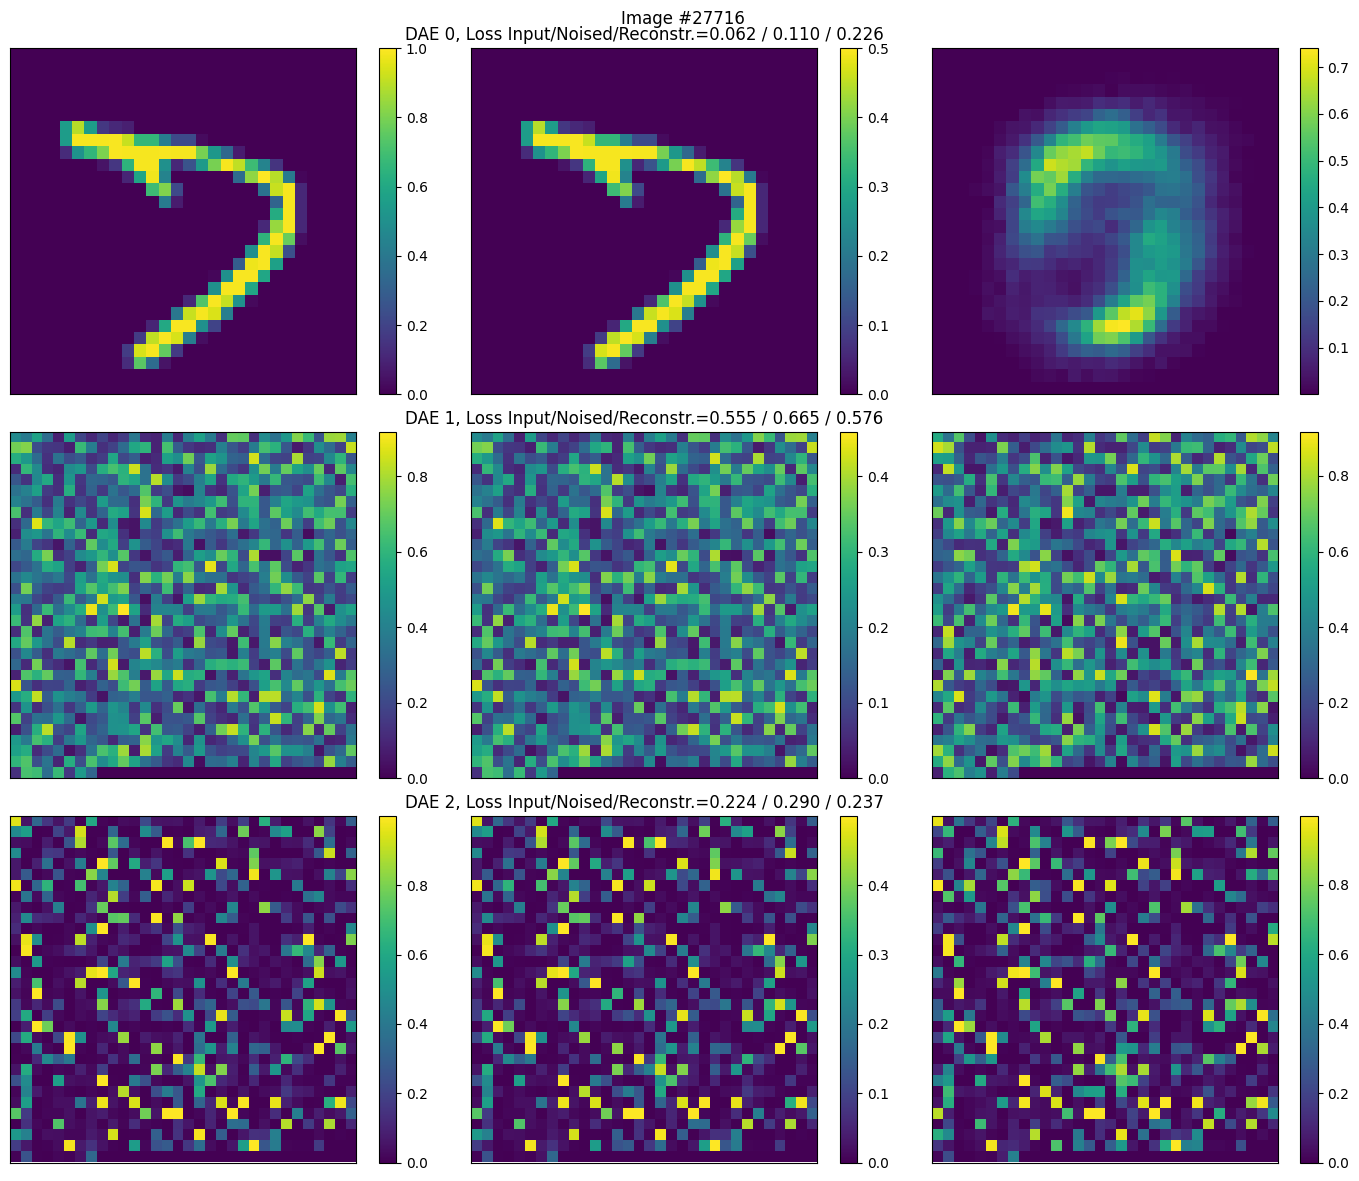

In [111]:
# @launchit.disable
fig, axes = plt.subplots(3, 3, subplot_kw={'yticks': [], 'xticks': []})
axes = axes.ravel()
fig.set_figwidth(14)
fig.set_figheight(4 * 3)

example_item_ind = RNG.choice(len(pretrain_dataset))
noise_func = noise_funcs[HP.pretraining.noise]
pretrain_model.eval()
loss_fn = losses[HP.pretraining.loss]()

with torch.no_grad():
    for target_dae_ind, base_ax_ind in zip(range(len(pretrain_model.daes)), range(len(axes))[::3]):
        batch = pretrain_dataset[example_item_ind].reshape(1, -1).to(CONFIG.cuda_device)
    
        for i in range(target_dae_ind):
            batch = pretrain_model.daes[i].encode(batch)

        noised = noise_func(batch)
        fr = pretrain_model.daes[target_dae_ind](noised)
        reconstructed = fr.reconstructed.to(device='cpu').detach()
        activations = fr.activations.to(device='cpu').detach()
        noised = fr.noised.to(device='cpu').detach()
        noised = noised / fr.noised_scale_factor
        batch = batch.to(device='cpu')

        ax1, ax2, ax3 = axes[base_ax_ind], axes[base_ax_ind+1], axes[base_ax_ind+2]

        im = ax1.imshow(ArrayUtils.v2sm(batch.numpy().ravel(), 0))
        fig.colorbar(im, ax=ax1)
        im = ax2.imshow(ArrayUtils.v2sm(noised.numpy().ravel(), 0))
        fig.colorbar(im, ax=ax2)
        im = ax3.imshow(ArrayUtils.v2sm(reconstructed.numpy().ravel(), 0))
        fig.colorbar(im, ax=ax3)
        loss1 = compute_regularized_loss(batch, batch, activations, loss_fn, HP.pretraining.regularization)
        loss2 = compute_regularized_loss(noised, batch, activations, loss_fn, HP.pretraining.regularization)
        loss3 = compute_regularized_loss(reconstructed, batch, activations, loss_fn, HP.pretraining.regularization)
        ax2.set_title(f'DAE {target_dae_ind}, Loss Input/Noised/Reconstr.={loss1:.3f} / {loss2:.3f} / {loss3:.3f}');
        
fig.suptitle(f'Image #{example_item_ind}');
fig.tight_layout()

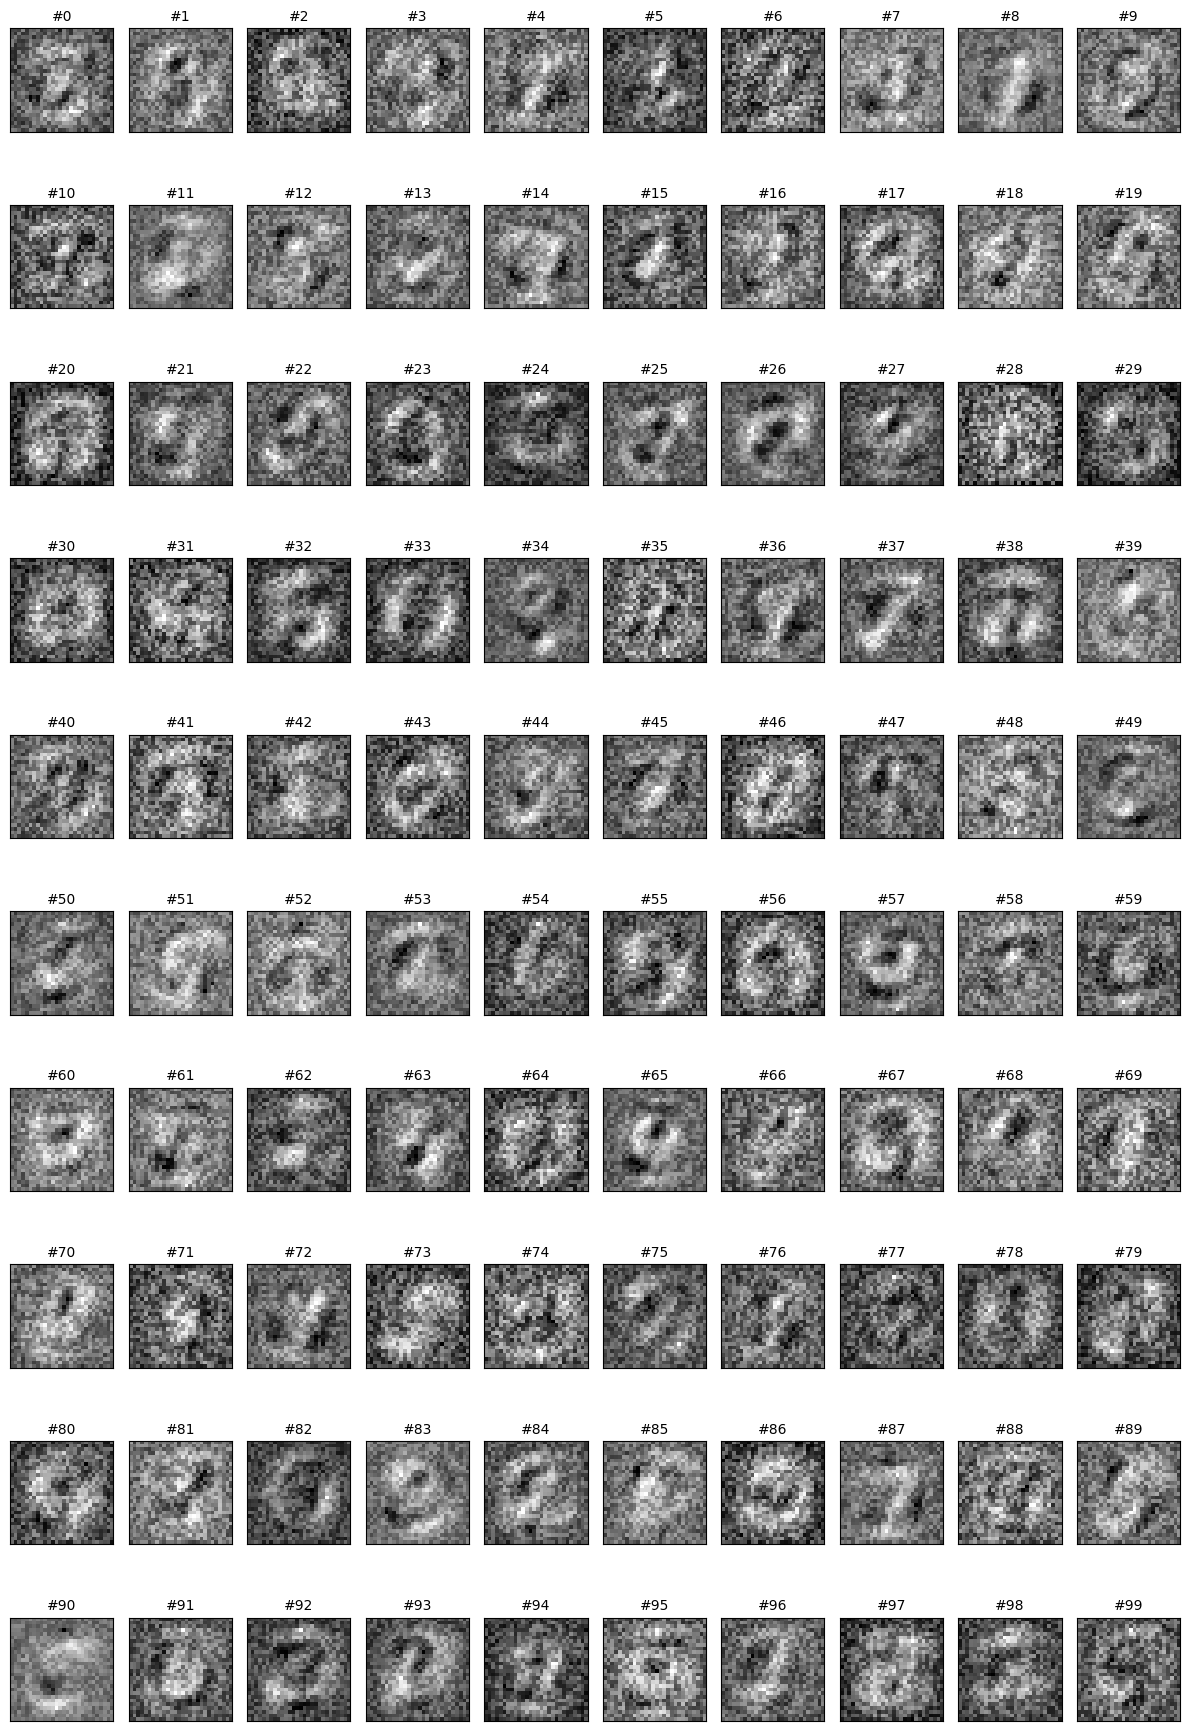

In [112]:
# @launchit.disable
bases_in_row = 10
max_filters_to_show = 100
fig, axes = plt.subplots(
    int(np.ceil(min(max_filters_to_show, pretrain_model.daes[0].encoder.out_features) / bases_in_row)), 
    bases_in_row,
    subplot_kw={'yticks': [], 'xticks': []}
)
fig.set_figwidth(12)
fig.set_figheight(18)
filters = pretrain_model.daes[0].encoder.weight.to(device='cpu').detach()

for i, (f, ax) in enumerate(zip(filters, axes.ravel())):
    ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
    ax.imshow(ArrayUtils.v2sm(f), cmap='gray')

plt.tight_layout()

# Supervised training via cross-validation

Alternatively, as illustrated in Figure 4, a logistic regression layer can be added on top of the encoders, yielding a deep neural network amenable to supervised learning. The parameters of **all layers** can then be **simultaneously fine-tuned** using a gradient-based procedure such as stochastic gradient descent. 

## Dataset

In [113]:
def create_dataset_for_supervised_training(name, scaler):
    images, labels = get_mnist_images(name)
    images, scaler = preprocess_images(images, HP.images.preprocessing, scaler)
    images = torch.Tensor(images)
    images = images.contiguous() # force dense memory layout (speeds up DataLoader x2 in case of any transposes within preprocess_images)
    dataset = StackDataset(images, labels)
    return dataset, scaler

In [114]:
train_dataset, scaler = create_dataset_for_supervised_training('TRAIN', scaler=None)
test_dataset, _ = create_dataset_for_supervised_training('TEST', scaler=scaler)

## Load pretrained model

In [115]:
# @launchit.disable_1
if HP.override_pretrain_model_version is not None:
    model_registry = new_model_registry()
    meta = json.load(io.BytesIO(model_registry.get_asset_content(LAUNCH_PROBLEM.model_name, HP.override_pretrain_model_version, asset_ext='json', asset_classifier='meta')))
    old_hp = Hyperparameters.from_dict(meta['hypers'])
    LOG(pprint.pformat(old_hp._asdict()))
    pretrain_model = StackedDAE(train_dataset.datasets[0].shape[1], old_hp.pretrain_model)
    pretrain_model = pretrain_model.to(device=CONFIG.cuda_device)
    pt_data = model_registry.get_asset_content(LAUNCH_PROBLEM.model_name, HP.override_pretrain_model_version, asset_ext='pt', asset_classifier='pretrain')
    pt_data = io.BytesIO(initial_bytes=pt_data)
    checkpoint = torch.load(pt_data, map_location=torch.device(CONFIG.cuda_device))
    pretrain_model.load_state_dict(checkpoint['model_state_dict'])
    LOG(f'Pretrain model instance loaded for version={HP.override_pretrain_model_version}')

## Model: DeepLinearRegression

In [116]:
class DeepLinearRegression(tnn.Module):
    def __init__(self, stacked_dae, classes_count):
        super().__init__()
        self.stacked_dae = stacked_dae
        self.linear_regression = tnn.Linear(stacked_dae.daes[-1].encoder.out_features, classes_count)

    def forward(self, inp):
        encoded = self.stacked_dae.encode(inp)
        return self.linear_regression(encoded)

In [117]:
# @launchit.disable
model = DeepLinearRegression(pretrain_model, 10)
sum([p.numel() for p in model.parameters()])

2799794

## Training via cross-validation

In [118]:
# @launchit.disable
# @launchit.collect_1
HP.training.batch_size = 100
HP.training.epochs_count = 1
HP.training.optimizer = 'Adam'
HP.training.learn_rate = 0.001
HP.training.cv_folds_count = 5
# @launchit.stop
# @launchit.stop
LOG(pprint.pformat(HP._asdict()))

{'images': {'preprocessing': 'UNINORM'},
 'override_pretrain_model_version': None,
 'pretrain_model': {'daes_count': 3,
                    'filters_count': 1000,
                    'hid_dropout': 0.5,
                    'inp_dropout': 0.5,
                    'is_bias': True,
                    'is_tied_weights': True,
                    'nonlinearity': {'decoder': 'sigmoid',
                                     'encoder': 'sigmoid'}},
 'pretraining': {'batch_size': 1000,
                 'epochs_count': 1,
                 'learn_rate': 0.005,
                 'loss': 'BCE',
                 'noise': 'None',
                 'optimizer': 'Adam',
                 'regularization': None},
 'random_seed': 82,
 'training': {'batch_size': 100,
              'cv_folds_count': 5,
              'epochs_count': 1,
              'learn_rate': 0.001,
              'optimizer': 'Adam'}}


In [119]:
# @launchit.disable_1
classes_count = 10
assert torch.all(train_dataset.datasets[1].unique() == torch.arange(classes_count))
k_fold = KFold(HP.training.cv_folds_count, shuffle=True, random_state=HP.random_seed)
metrics_suite = defaultdict(list)
optuna_trial = optuna_multiprocessing.get_trial()

for fold_ind, (train_inds, val_inds) in tqdm(enumerate(k_fold.split(train_dataset)), desc='Fold', total=HP.training.cv_folds_count, disable=not CONFIG.is_interactive):
    with LOG.auto_prefix('FOLD', fold_ind):
        data_loader = DataLoader(StackDataset(*train_dataset[train_inds]), batch_size=HP.training.batch_size, shuffle=True)
        val_images = train_dataset[val_inds][0].to(device=CONFIG.cuda_device)
        val_labels = train_dataset[val_inds][1].to(device=CONFIG.cuda_device)
        model = DeepLinearRegression(copy.deepcopy(pretrain_model), classes_count)
        model = model.to(device=CONFIG.cuda_device)
        loss_fn = tnn.CrossEntropyLoss()
        optimizer = getattr(topt, HP.training.optimizer)(model.parameters(), lr=HP.training.learn_rate)
        fold_metrics_suite = defaultdict(list)
    
        for epoch_ind in tqdm(range(HP.training.epochs_count), 'Epoch', disable=not CONFIG.is_interactive):
            epoch = epoch_ind + 1
            
            with LOG.auto_prefix('EPOCH', epoch):
                train_loss_sum, train_loss_denom = 0, 0
                train_accuracy_sum, train_accuracy_denom = 0, 0
                
                for batch in data_loader:
                    optimizer.zero_grad()
                    
                    images = batch[0].to(device=CONFIG.cuda_device)
                    labels = batch[1].to(device=CONFIG.cuda_device)
                    logits = model(images)
                    loss = loss_fn(logits, labels)
                    loss.backward()
                    
                    optimizer.step()
                    
                    train_loss_sum += loss.item() * len(batch)
                    train_loss_denom += len(batch)
                    train_accuracy_sum += (logits.argmax(axis=1) == labels).sum().item() # how many correct predictions
                    train_accuracy_denom += len(labels)
            
                assert train_loss_denom > 0
                assert train_accuracy_denom > 0
                train_loss = train_loss_sum / train_loss_denom
                train_accuracy = train_accuracy_sum / train_accuracy_denom
                fold_metrics_suite['train_loss'].append(train_loss)
                fold_metrics_suite['train_accuracy'].append(train_accuracy)
            
                with torch.no_grad():
                    val_logits = model(val_images)
                    val_loss = loss_fn(val_logits, val_labels).item()
                    predicted_val_labels = val_logits.argmax(axis=1)
                    val_accuracy = (predicted_val_labels == val_labels).sum().item() / len(val_labels)
                    fold_metrics_suite['val_loss'].append(val_loss)
                    fold_metrics_suite['val_accuracy'].append(val_accuracy)

                LOG(f'{train_loss=}, {train_accuracy=}, {val_loss=}, {val_accuracy=}', when=not CONFIG.is_interactive)
                
                if optuna_trial is not None and fold_ind == 0:
                    # https://optuna.readthedocs.io/en/stable/reference/generated/optuna.trial.Trial.html#optuna.trial.Trial.report:
                    # > If this method is called multiple times at the same step in a trial, the reported value only the first time is stored 
                    # > and the reported values from the second time are ignored.
                    # In other words calling report for fold other than the first one does nothing except producing tons of warnings in console. 
                    # As such only the first fold is indicative
                    optuna_trial.report(val_accuracy, epoch_ind) # "Note that pruners assume that step starts at zero" -> as such use epoch_ind instead of epoch
            
                    if optuna_trial.should_prune():
                        # Despite written in docs OPTUNA_TRIAL.should_prune is not idempotent - consequent calls could lead
                        # to different responses. Perhapse this is due to influence of concurrent trials running which could change
                        # pruner decision. As such cache pruning result so it's immutable
                        optuna_trial.set_user_attr('IS_PRUNED', True)
                        break
    
        for metric_name, metric_values in fold_metrics_suite.items():
            metrics_suite[metric_name].append(metric_values)
    
        if 'IS_PRUNED' in getattr(optuna_trial, 'user_attrs', {}):
            LOG(f'Optuna pruning condition encountered. Stopping training')
            break
    
for metric_name in list(metrics_suite.keys()):
    metric_values = metrics_suite[metric_name]
    metric_values = np.array(metric_values)
    # According to Optuna docs we could get pruned only on first fold (report() calls is ignored on successive folds).
    # As such we either should have 1) a full-fledged metrcs_suite (for all folds and for each epoch)
    # or 2) only metrics from the very first fold
    if 'IS_PRUNED' in getattr(optuna_trial, 'user_attrs', {}):
        assert len(metric_values) == 1
        assert metric_values.shape[1] <= HP.training.epochs_count
    else:
        assert len(metric_values) == HP.training.cv_folds_count
        assert metric_values.shape[1] == HP.training.epochs_count
        
    mean_values = list(metric_values.mean(axis=0)) # coercing to list since json.dump throws "np.ndarray is not serializable"
    std_values = list(metric_values.std(axis=0)) # coercing to list since json.dump throws "np.ndarray is not serializable"
    metrics_suite['mean_' + metric_name] = mean_values
    metrics_suite['std_' + metric_name] = std_values
    assert len(mean_values) == len(std_values)
    
    for epoch_ind in range(min(HP.training.epochs_count, len(mean_values))):
        epoch = epoch_ind + 1
        summary_writer.add_scalar('mean_' + metric_name, mean_values[epoch_ind], epoch)
        summary_writer.add_scalar('std_' + metric_name, std_values[epoch_ind], epoch)
        
    summary_writer.flush()   

METRICS_SUITE.update(metrics_suite)

Fold:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

## Save

In [120]:
# @launchit.disable_1
model_registry = new_model_registry()

with io.BytesIO() as b:
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'hypers': HP._asdict(),
    }, b)
    model_registry.attach_asset(LAUNCH_PROBLEM.model_name, LAUNCH_PROBLEM.model_version, b, asset_ext='pt', asset_classifier='train', replace=True)

with io.StringIO() as b:
    json.dump(METRICS_SUITE, b)
    model_registry.attach_asset(LAUNCH_PROBLEM.model_name, LAUNCH_PROBLEM.model_version, b, asset_ext='json', asset_classifier='metrics', replace=True)

# Supervised training for test_accuracy

## Load pretrained hypers, model, metrics

In [ ]:
if LAUNCH_PROBLEM.goal == LaunchGoal.TEST_ACCURACY:
    model_registry = new_model_registry()
    
    meta = json.load(io.BytesIO(model_registry.get_asset_content(LAUNCH_PROBLEM.model_name, LAUNCH_PROBLEM.model_version, asset_ext='json', asset_classifier='meta')))
    HP = Hyperparameters.from_dict(meta['hypers'])
    LOG(f'Hyperparameters loaded for version={LAUNCH_PROBLEM.model_version}:\n{pprint.pformat(HP._asdict())}')

    pretrain_model = StackedDAE(train_dataset.datasets[0].shape[1], HP.pretrain_model)
    pretrain_model = pretrain_model.to(device=CONFIG.cuda_device)
    pt_data = model_registry.get_asset_content(LAUNCH_PROBLEM.model_name, LAUNCH_PROBLEM.model_version, asset_ext='pt', asset_classifier='pretrain')
    pt_data = io.BytesIO(initial_bytes=pt_data)
    checkpoint = torch.load(pt_data, map_location=torch.device(CONFIG.cuda_device))
    pretrain_model.load_state_dict(checkpoint['model_state_dict'])
    LOG(f'Pretrain model instance loaded for version={LAUNCH_PROBLEM.model_version}')

    old_metrics_suite = json.load(io.BytesIO(model_registry.get_asset_content(LAUNCH_PROBLEM.model_name, LAUNCH_PROBLEM.model_version, asset_ext='json', asset_classifier='metrics')))
    METRICS_SUITE.update(old_metrics_suite)
    LOG(f'Metrics suite loaded for version={LAUNCH_PROBLEM.model_version}')

## Training on whole dataset (test_accuracy)

In [ ]:
# @launchit.disable_2
classes_count = 10
assert torch.all(train_dataset.datasets[1].unique() == torch.arange(classes_count))
data_loader = DataLoader(train_dataset, batch_size=HP.training.batch_size, shuffle=True)
test_images = test_dataset.datasets[0].to(device=CONFIG.cuda_device)
test_labels = test_dataset.datasets[1].to(device=CONFIG.cuda_device)
model = DeepLinearRegression(copy.deepcopy(pretrain_model), classes_count)
model = model.to(device=CONFIG.cuda_device)
loss_fn = tnn.CrossEntropyLoss()
optimizer = getattr(topt, HP.training.optimizer)(model.parameters(), lr=HP.training.learn_rate)

for epoch_ind in tqdm(range(HP.training.epochs_count), 'Epoch', disable=not CONFIG.is_interactive):
    epoch = epoch_ind + 1
    train_loss_sum, train_loss_denom = 0, 0
    train_accuracy_sum, train_accuracy_denom = 0, 0
    
    for batch in data_loader:
        optimizer.zero_grad()
        
        images = batch[0].to(device=CONFIG.cuda_device)
        labels = batch[1].to(device=CONFIG.cuda_device)
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        
        optimizer.step()
        
        train_loss_sum += loss.item() * len(batch)
        train_loss_denom += len(batch)
        train_accuracy_sum += (logits.argmax(axis=1) == labels).sum().item() # how many correct predictions
        train_accuracy_denom += len(labels)

    assert train_loss_denom > 0
    assert train_accuracy_denom > 0
    train_loss = train_loss_sum / train_loss_denom
    train_accuracy = train_accuracy_sum / train_accuracy_denom
    summary_writer.add_scalar('train_loss', train_loss, epoch)
    summary_writer.add_scalar('train_accuracy', train_accuracy, epoch)
    METRICS_SUITE['train_loss'].append(train_loss)
    METRICS_SUITE['train_accuracy'].append(train_accuracy)

    with torch.no_grad():
        test_logits = model(test_images)
        test_loss = loss_fn(test_logits, test_labels).item()
        predicted_test_labels = test_logits.argmax(axis=1)
        test_accuracy = (predicted_test_labels == test_labels).sum().item() / len(test_labels)
        summary_writer.add_scalar('test_loss', test_loss, epoch)
        summary_writer.add_scalar('test_accuracy', test_accuracy, epoch)
        METRICS_SUITE['test_loss'].append(test_loss)
        METRICS_SUITE['test_accuracy'].append(test_accuracy)
        
    summary_writer.flush()

## Save

In [ ]:
# @launchit.disable_2
model_registry = new_model_registry()

with io.BytesIO() as b:
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'hypers': HP._asdict(),
    }, b)
    model_registry.attach_asset(LAUNCH_PROBLEM.model_name, LAUNCH_PROBLEM.model_version, b, asset_ext='pt', asset_classifier='full_train', replace=True)

with io.StringIO() as b:
    json.dump(METRICS_SUITE, b)
    model_registry.attach_asset(LAUNCH_PROBLEM.model_name, LAUNCH_PROBLEM.model_version, b, asset_ext='json', asset_classifier='metrics', replace=True)

# Publish trial result

In [121]:
# @launchit.disable_1
optuna_trial = optuna_multiprocessing.get_trial()

if optuna_trial is not None:
    if 'IS_PRUNED' in optuna_trial.user_attrs:
        raise optuna.exceptions.TrialPruned()

    if not METRICS_SUITE:
        LOG(f'Empty metrics suite. Cancelling model')
        optuna_multiprocessing.save_trial_result(0)
    else:
        match LAUNCH_PROBLEM.goal:
            case LaunchGoal.PRETRAIN_LOSS:
                last_pretrain_losses = []
                
                for i in range(HP.pretrain_model.daes_count):
                    last_pretrain_losses.append(METRICS_SUITE[f'pretrain_loss_{i}'][-1])

                last_pretrain_losses = tuple(last_pretrain_losses)
                optuna_multiprocessing.save_trial_result(last_pretrain_losses)
                LOG(f'Pretrain objective result={last_pretrain_losses')
            case LaunchGoal.E2E:
                last_std_val_accuracy = METRICS_SUITE['std_val_accuracy'][-1]
                last_mean_val_accuracy = METRICS_SUITE['mean_val_accuracy'][-1]
                    
                if last_std_val_accuracy > 0.05:
                    LOG(f'Unstable condition encountered: {last_mean_val_accuracy=}, {last_std_val_accuracy=}. Cancelling model')
                    optuna_multiprocessing.save_trial_result(0)
                else:
                    optuna_multiprocessing.save_trial_result(last_mean_val_accuracy)
                    LOG(f'Train objective result={last_mean_val_accuracy}')
            case _:
                assert False, f'Unsupported {LAUNCH_PROBLEM.exec_goal=}'

# Launch creation

## Manual for pretraining/training

In [122]:
# @launchit.disable
launchit_t0 = time.time()

In [11]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    model_version = int(Autoincrement.get(f'{LAUNCH_PROBLEM.model_group_uri}.{LAUNCH_PROBLEM.model_name}'))
    assert model_version > 0, model_version
    model_registry_obj = new_model_registry(is_real=True)
    model_registry_obj.register_model(LAUNCH_PROBLEM.model_name, model_version)
    LOG(f'Model instance registered, version={model_version}')
    
    expandvars = dict(
        PROJECT_ROOT_PATH=CONFIG.project_root_path,
        MODEL_GROUP_URI=LAUNCH_PROBLEM.model_group_uri,
        MODEL_NAME=LAUNCH_PROBLEM.model_name,
        MODEL_VERSION=model_version,
        LAUNCH_GOAL='e2e',
    )
    launch_notebook_fname = launchit.launchit(CONFIG.self_fname, launch_serial=model_version, expandvars=expandvars, collect_inds=[1], disable_inds=[2])
    LOG(f'Created launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Model instance registered, version=263
Creating /home/misha/dev/mine/neurovision/denoise/s3_stacked_dae_09-launch263.ipynb
Created launch notebook "/home/misha/dev/mine/neurovision/denoise/s3_stacked_dae_09-launch263.ipynb"


## Manual for test accuracy

In [7]:
# @launchit.disable
launchit_t0 = time.time()

In [17]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    model_version = 262 # specify desired model version here
    
    expandvars = dict(
        PROJECT_ROOT_PATH=CONFIG.project_root_path,
        MODEL_GROUP_URI=LAUNCH_PROBLEM.model_group_uri,
        MODEL_NAME=LAUNCH_PROBLEM.model_name,
        MODEL_VERSION=model_version,
        LAUNCH_GOAL='test_accuracy',
    )
    launch_notebook_fname = launchit.launchit(CONFIG.self_fname, launch_serial=model_version, expandvars=expandvars, collect_inds=[1], disable_inds=[1])
    LOG(f'Created launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Creating /home/misha/dev/mine/neurovision/denoise/s3_stacked_dae_09-launch262.ipynb
Created launch notebook "/home/misha/dev/mine/neurovision/denoise/s3_stacked_dae_09-launch262.ipynb"


## Optuna (model selection)

In [ ]:
# @launchit.disable
# @launchit.collect_2
optuna_trial = optuna_multiprocessing.get_trial()

if optuna_trial is not None:
    HP.random_seed = optuna_trial.suggest_categorical('random_seed', [3, 7, 42, 82, 100, 1945])
    
    HP.images.preprocessing = 'UNINORM'
    
    HP.pretrain_model.daes_count = 3
    HP.pretrain_model.filters_count = 1000
    HP.pretrain_model.is_tied_weights = True
    HP.pretrain_model.is_bias = True
    HP.pretrain_model.nonlinearity = {'encoder': 'sigmoid', 'decoder': 'sigmoid'}
    HP.pretrain_model.inp_dropout = 0.5 # analog to 'Masking_0.5', but much faster
    HP.pretrain_model.hid_dropout = 0.5 # analog to 'Masking_0.5', but much faster
    
    HP.pretraining.batch_size = 1000
    HP.pretraining.epochs_count = 300
    HP.pretraining.noise = 'None'
    HP.pretraining.optimizer = 'Adam'
    HP.pretraining.learn_rate = optuna_trial.suggest_float('pretraining.learn_rate', 0.005, 0.05)
    HP.pretraining.loss = 'BCE'
    HP.pretraining.regularization = None
    
    HP.training.batch_size = 500
    HP.training.epochs_count = optuna_trial.suggest_int('training.epochs_count', 50, 300, step=50)
    HP.training.optimizer = 'Adam'
    HP.training.learn_rate = optuna_trial.suggest_float('training.learn_rate', 0.0001, 0.1)
    HP.training.cv_folds_count = 5

In [ ]:
# optuna_trial = optuna_multiprocessing.get_trial()

# if optuna_trial is not None:
#     HP.images.preprocessing = 'UNINORM'
    
#     HP.pretrain_model.daes_count = 3
#     HP.pretrain_model.filters_count = 1000
#     HP.pretrain_model.is_tied_weights = True
#     HP.pretrain_model.is_bias = True
#     HP.pretrain_model.nonlinearity = {'encoder': 'sigmoid', 'decoder': 'sigmoid'}
#     HP.pretrain_model.inp_dropout = 0.2
#     HP.pretrain_model.hid_dropout = 0.5
    
#     HP.pretraining.batch_size = 500
#     HP.pretraining.epochs_count = 0
#     HP.pretraining.noise = 'None'
#     HP.pretraining.optimizer = 'Adam'
#     HP.pretraining.learn_rate = 0.001
#     HP.pretraining.loss = 'BCE'
#     HP.pretraining.regularization = None

#     HP.random_seed = optuna_trial.suggest_categorical('random_seed', [7, 42, 82, 100, 1945])
#     HP.override_pretrain_model_version = 71
    
#     HP.training.batch_size = 500
#     HP.training.epochs_count = optuna_trial.suggest_int('training.epochs_count', 50, 300, step=50)
#     HP.training.optimizer = 'Adam'
#     HP.training.learn_rate = optuna_trial.suggest_float('training.learn_rate', 0.0001, 0.1)
#     HP.training.cv_folds_count = 5

In [ ]:
# optuna_trial = optuna_multiprocessing.get_trial()

# if optuna_trial is not None:
#     HP.random_seed = optuna_trial.suggest_categorical('random_seed', [7, 42, 82, 100, 1945])
    
#     HP.images.preprocessing = 'UNINORM'
    
#     HP.pretrain_model.daes_count = 3
#     HP.pretrain_model.filters_count = 1000
#     HP.pretrain_model.is_tied_weights = True
#     HP.pretrain_model.is_bias = True
#     HP.pretrain_model.nonlinearity = {'encoder': 'sigmoid', 'decoder': 'sigmoid'}
#     HP.pretrain_model.inp_dropout = 0.5
#     HP.pretrain_model.hid_dropout = 0.5
    
#     HP.pretraining.batch_size = 1000
#     HP.pretraining.epochs_count = 300
#     HP.pretraining.noise = 'None'
#     HP.pretraining.optimizer = 'Adam'
#     HP.pretraining.learn_rate = optuna_trial.suggest_float('pretraining.learn_rate', 0.005, 0.05)
#     HP.pretraining.loss = 'BCE'
#     HP.pretraining.regularization = None
    
#     HP.training.batch_size = 500
#     HP.training.epochs_count = 0
#     HP.training.optimizer = 'Adam'
#     HP.training.learn_rate = 0.001
#     HP.training.cv_folds_count = 5

In [ ]:
# @launchit.disable
expandvars = dict(
    PROJECT_ROOT_PATH = CONFIG.project_root_path,
    MODEL_GROUP_URI=LAUNCH_PROBLEM.model_group_uri,
    MODEL_NAME=LAUNCH_PROBLEM.model_name,
    LAUNCH_GOAL='e2e',
)
# study_name = CONFIG.self_name
study_name = CONFIG.self_name + '_e2e_2'
# study_name = CONFIG.self_name + '_supervised_over_71'
# study_name = CONFIG.self_name + '_pretraining2'
rop_task = optuna_multiprocessing.RunOptimizationTask(
    app_name=CONFIG.self_name,
    is_stdout_enabled=False,
    notebook_fname=CONFIG.self_fname,
    notebook_name=CONFIG.self_name,
    model_group_uri=LAUNCH_PROBLEM.model_group_uri,
    model_name=LAUNCH_PROBLEM.model_name,
    expandvars=expandvars,
    collect_inds=[2],
    disable_inds=[2],
    run_path=CONFIG.run_path,
    study_name=study_name,
    study_fname=os.path.join(CONFIG.run_path, study_name + '.log'),
    optimize_direction='minimize' if 'pretrain' in study_name else 'maximize'
)
rop_tasks = [rop_task] * 4
mp_ctx = mp.get_context('spawn') # Req-d for CUDA, fork doesn't work within PyTorch

with mp_ctx.Pool(processes=4, maxtasksperchild=1) as pool:  # maxtasksperchild=1 forces fresh process for each trial to spare resources and avoid possible side effects of processe resue
    pool.map(optuna_multiprocessing.run_optimization, rop_tasks)

In [50]:
# @launchit.disable
study = optuna.create_study(
    study_name=rop_task.study_name,
    storage=JournalStorage(JournalFileBackend(file_path=rop_task.study_fname)),
    load_if_exists=True, 
)

pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

LOG('Study statistics: ')
LOG(f'  Number of finished trials: {len(study.trials)}')
LOG(f'  Number of pruned trials: {len(pruned_trials)}')
LOG(f'  Number of complete trials: {len(complete_trials)}')

LOG('Best trial:')
trial = study.best_trial

LOG(f'  Value: {trial.value}')
LOG(f'  Model version: {trial.user_attrs['MODEL_VERSION']}')

LOG('  Params: ')
for key, value in trial.params.items():
    LOG(f'    {key}: {value}')

[I 2026-01-29 10:25:48,486] Using an existing study with name 's3_stacked_dae_09_e2e_2' instead of creating a new one.


Study statistics: 
  Number of finished trials: 99
  Number of pruned trials: 69
  Number of complete trials: 29
Best trial:
  Value: 0.9873166666666666
  Model version: 245
  Params: 
    random_seed: 1945
    pretraining.learn_rate: 0.005246968615213398
    training.epochs_count: 150
    training.learn_rate: 0.005932751853304337


# Supervised training: SVC

In [29]:
# @launchit.disable
if CONFIG.is_cuml:
    LOG('Running with CuML')
    import cuml
    cuml.accel.install(log_level="debug")
else:
    LOG('Running without CuML')

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC, LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

Running with CuML
[cuml.accel] Enabled managed memory.
[cuml.accel] Accelerator installed.


## Pretrained model

To this end, we fed the representations learnt by the purely unsupervised phase of SDAE, at increasing higher levels (first, second and third hidden layer) to both a linear SVM and a Kernel SVM (using a RBF kernel). The hyperparameters of the SVM and its kernel were tuned on the validation set as usual. For computational reasons, we did not re-tune SDAE hyperparameters. Instead, we identified the best performing SDAE-pretrained neural networks with 1000 units per layer, based on their validation performance after fine-tuning from previous experiments, but used their saved weights prior to fine-tuning (i.e., after unsupervised denoising training only).

In [30]:
# @launchit.disable
LAUNCH_PROBLEM = LAUNCH_PROBLEM._replace(model_version=17) # <- specifty desired one
pretrain_stacked_dae_asset_classifier = 'pretrain'

# LAUNCH_PROBLEM = LAUNCH_PROBLEM._replace(model_version=86) # <- specifty desired one
# pretrain_stacked_dae_asset_classifier = 'train' # aka fine-tuned (some sort of cheating, because trained model was selected based on test accuracy, i.e. is somewhat biased)

In [31]:
# @launchit.disable
train_images, _ = get_mnist_images('TRAIN')
model_registry = new_model_registry(is_real=True)
meta = json.load(io.BytesIO(model_registry.get_asset_content(LAUNCH_PROBLEM.model_name, LAUNCH_PROBLEM.model_version, asset_ext='json', asset_classifier='meta')))
old_hp = Hyperparameters.from_dict(meta['hypers'])
LOG(pprint.pformat(old_hp._asdict()))

pretrain_model = StackedDAE(train_images.shape[1], old_hp.pretrain_model)
pretrain_model = pretrain_model.to(device=CONFIG.cuda_device)
pt_data = model_registry.get_asset_content(LAUNCH_PROBLEM.model_name, LAUNCH_PROBLEM.model_version, asset_ext='pt', pretrain_stacked_dae_asset_classifier)
pt_data = io.BytesIO(initial_bytes=pt_data)
checkpoint = torch.load(pt_data, map_location=torch.device(CONFIG.cuda_device))

if pretrain_stacked_dae_asset == 'pretrain_pt':
    pretrain_model.load_state_dict(checkpoint['model_state_dict'])
elif pretrain_stacked_dae_asset == 'train_pt':
    fined_tuned_model = DeepLinearRegression(pretrain_model, 10)
    fined_tuned_model.load_state_dict(checkpoint['model_state_dict']) # implicit load of pretrain model
else:
    assert False, pretrain_stacked_dae_asset
    
pretrain_model.eval()

{'images': {'preprocessing': 'UNINORM'},
 'override_pretrain_model_version': None,
 'pretrain_model': {'daes_count': 3,
                    'filters_count': 1000,
                    'is_bias': True,
                    'is_tied_weights': True,
                    'nonlinearity': {'decoder': 'sigmoid',
                                     'encoder': 'sigmoid'}},
 'pretraining': {'batch_size': 1000,
                 'epochs_count': 300,
                 'learn_rate': 0.01,
                 'loss': 'BCE',
                 'noise': 'Masking_0.4',
                 'optimizer': 'Adam',
                 'regularization': None},
 'random_seed': None,
 'training': {'batch_size': 1000,
              'epochs_count': 500,
              'learn_rate': 0.001,
              'optimizer': 'Adam'}}


StackedDAE(
  (daes): ModuleList(
    (0): DenoiseAutoencoder(
      (encoder): Linear(in_features=784, out_features=1000, bias=True)
    )
    (1-2): 2 x DenoiseAutoencoder(
      (encoder): Linear(in_features=1000, out_features=1000, bias=True)
    )
  )
)

## Train & test datasets

In [32]:
# @launchit.disable
def create_dataset_for_classification(images, image_labels, model, encode_depth=-1):
    features_list = []
    labels_list = []
    assert len(images) == len(image_labels)
    data_loader = DataLoader(list(zip(torch.Tensor(images), image_labels)), batch_size=100)
    
    for images, labels in tqdm(data_loader, disable=not CONFIG.is_interactive):
        images = torch.Tensor(images).to(device=CONFIG.cuda_device)
        
        with torch.no_grad():
            features = model.encode(images, encode_depth)
            features_list.append(features.cpu().numpy())
            labels_list.append(labels.numpy())
    
    x = np.vstack(features_list).astype('float64') # float64 is recommended for SVC
    y = np.hstack(labels_list)
    return x, y

In [44]:
# @launchit.disable
encode_depth = 3

train_images, train_image_labels = get_mnist_images('TRAIN')
train_images, train_images_scaler = preprocess_images(train_images, HP.images.preprocessing)
x_train, y_train = create_dataset_for_classification(train_images, train_image_labels, pretrain_model, encode_depth)

test_images, test_image_labels = get_mnist_images('TEST')
test_images, _ = preprocess_images(test_images, HP.images.preprocessing, train_images_scaler) # train_images_scaler is a must!!!
x_test, y_test = create_dataset_for_classification(test_images, test_image_labels, pretrain_model, encode_depth)

  0%|          | 0/600 [00:00<?, ?it/s]

## SVC

In [46]:
# @launchit.disable
n_jobs = None if CONFIG.is_cuml else -1 # using all CPUs (-1) showed to be a bad idea with CUML - no perf gain, but huge impact on CPU and GPU

pipeline = make_pipeline(
    StandardScaler(),
    LDA(),
    LinearSVC(),
)
pipeline = make_pipeline(
    StandardScaler(),
    LinearSVC(),
)
pipeline = make_pipeline(
    LinearSVC(),
)
parameters = {
    'linearsvc__C': np.linspace(0.01, 1, 10),
    'linearsvc__max_iter': [100],
    # 'penalty': ['l1', 'l2'],
    'linearsvc__random_state': [HP.random_seed],
}
# pipeline = make_pipeline(
#     StandardScaler(),
#     LDA(),
#     SVC(),
# )
# pipeline = make_pipeline(
#     StandardScaler(),
#     SVC(),
# )
# parameters = {
#     'svc__C': np.linspace(3, 6, 10),
#     'svc__kernel': ['rbf'],
#     'svc__max_iter': [300],
#     'svc__cache_size': [1_000],
#     'svc__random_state': [HP.random_seed],
# }
search = GridSearchCV(pipeline, parameters, n_jobs=n_jobs)
search.fit(x_train, y_train)
svc = search.best_estimator_
svc.score(x_test, y_test)

# parameters = {'C': np.linspace(0.01, 1, 3), 'penalty': ['l1', 'l2'], 'max_iter': [100], 'random_state': [HP.random_seed]}
# parameters = {'C': np.linspace(0.01, 1, 3), 'max_iter': [100], 'random_state': [HP.random_seed]}
# search_svm = GridSearchCV(LinearSVC(), parameters, n_jobs=n_jobs)

# parameters = {'C': np.linspace(0.01, 1, 10), 'kernel': ['linear', 'rbf'], 'max_iter': [1000], 'random_state': [HP.random_seed]}
# parameters = {'C': np.linspace(3, 5, 5), 'gamma': np.linspace(0.01, 1, 5), 'kernel': ['rbf'], 'max_iter': [1000], 'random_state': [HP.random_seed]}
# search_svm = GridSearchCV(SVC(cache_size=1_000), parameters, n_jobs=n_jobs)

# svm = SVC(max_iter=300, kernel='rbf', C=1, cache_size=1_000, random_state=HP.random_seed) # version=2, 0.9772
# svm = SVC(max_iter=300, kernel='rbf', C=1.5, cache_size=1_000, random_state=HP.random_seed) # version=2, 0.9805
# svm = SVC(max_iter=300, kernel='rbf', C=4.555, cache_size=1_000, random_state=HP.random_seed) # version=2, 0.9808
# svm = SVC(max_iter=2_000, kernel='rbf', C=4.555, cache_size=1_000, random_state=HP.random_seed) # version=2, 0.9808
# svm = SVC(max_iter=100, kernel='rbf', C=3.8889, cache_size=1_000, random_state=HP.random_seed) # version=2, 0.9808
# svm.fit(x_train, y_train)

[cuml.accel] `LinearSVC.fit` ran on GPU
[cuml.accel] `LinearSVC.score` ran on GPU
[cuml.accel] `LinearSVC.fit` ran on GPU
[cuml.accel] `LinearSVC.score` ran on GPU
[cuml.accel] `LinearSVC.fit` ran on GPU
[cuml.accel] `LinearSVC.score` ran on GPU
[cuml.accel] `LinearSVC.fit` ran on GPU
[cuml.accel] `LinearSVC.score` ran on GPU
[cuml.accel] `LinearSVC.fit` ran on GPU
[cuml.accel] `LinearSVC.score` ran on GPU
[cuml.accel] `LinearSVC.fit` ran on GPU
[cuml.accel] `LinearSVC.score` ran on GPU
[cuml.accel] `LinearSVC.fit` ran on GPU
[cuml.accel] `LinearSVC.score` ran on GPU
[cuml.accel] `LinearSVC.fit` ran on GPU
[cuml.accel] `LinearSVC.score` ran on GPU
[cuml.accel] `LinearSVC.fit` ran on GPU
[cuml.accel] `LinearSVC.score` ran on GPU
[cuml.accel] `LinearSVC.fit` ran on GPU
[cuml.accel] `LinearSVC.score` ran on GPU
[cuml.accel] `LinearSVC.fit` ran on GPU
[cuml.accel] `LinearSVC.score` ran on GPU
[cuml.accel] `LinearSVC.fit` ran on GPU
[cuml.accel] `LinearSVC.score` ran on GPU
[cuml.accel] `Li

0.9776

## SVC performance

In [72]:
# @launchit.disable
accuracy = svc.score(x_test, y_test)
LOG(f'Accuracy={accuracy}')

parameters = {
    'C': svc.C, 
    'max_iter': svc.max_iter, 
    'random_state': svc.random_state, 
}

if isinstance(svc, SVC):
    parameters['kernel'] = svc.kernel
    parameters['gamma'] = svc.gamma
elif isinstance(svc, LinearSVC):
    parameters['penalty'] = svc.penalty
    parameters['loss'] = svc.loss
    
summary_log_dir = os.path.join(LAUNCH_PROBLEM.model_name, str(LAUNCH_PROBLEM.model_version))
new_summary_writer(log_dir=summary_log_dir, is_real=True).add_hparams(
    parameters, 
    {'accuarcy': accuracy},
    run_name=f'{datetime.datetime.now().strftime('%y%m%d:%H%M%S')}')

CPU times: user 1min 9s, sys: 12.6 ms, total: 1min 9s
Wall time: 1min 9s


0.9805